In [637]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [638]:
os.makedirs('figures', exist_ok=True)

In [639]:
demo = pd.read_sas("DEMO_J.xpt")
bp = pd.read_sas("BPX_J.xpt")
bpq = pd.read_sas("BPQ_J.xpt")
pa = pd.read_sas("PAQ_J.xpt")

In [640]:
print(demo.head())
print(bp.head())
print(bpq.head())
print(pa.head())

      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  93703.0      10.0       2.0       2.0       2.0       NaN       5.0   
1  93704.0      10.0       2.0       1.0       2.0       NaN       3.0   
2  93705.0      10.0       2.0       2.0      66.0       NaN       4.0   
3  93706.0      10.0       2.0       1.0      18.0       NaN       5.0   
4  93707.0      10.0       2.0       1.0      13.0       NaN       5.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DMDHREDZ  DMDHRMAZ  DMDHSEDZ  \
0       6.0       2.0      27.0  ...       3.0       1.0       3.0   
1       3.0       1.0      33.0  ...       3.0       1.0       2.0   
2       4.0       2.0       NaN  ...       1.0       2.0       NaN   
3       6.0       2.0     222.0  ...       3.0       1.0       2.0   
4       7.0       2.0     158.0  ...       2.0       1.0       3.0   

       WTINT2YR      WTMEC2YR  SDMVPSU  SDMVSTRA  INDHHIN2  INDFMIN2  INDFMPIR  
0   9246.491865   8539.731348      2.0     145.0     

## DATA CLEANING

In [641]:
demo = demo[demo["RIDAGEYR"].between(20,80)]

In [642]:
demo

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8.338420e+03,2.0,145.0,3.0,3.0,0.82
5,93708.0,10.0,2.0,2.0,66.0,NaN,5.0,6.0,2.0,NaN,...,1.0,1.0,1.0,13329.450589,1.437249e+04,2.0,138.0,6.0,6.0,1.63
6,93709.0,10.0,2.0,2.0,75.0,NaN,4.0,4.0,1.0,NaN,...,2.0,2.0,NaN,12043.388271,1.227756e+04,1.0,136.0,2.0,2.0,0.41
8,93711.0,10.0,2.0,1.0,56.0,NaN,5.0,6.0,2.0,NaN,...,3.0,1.0,3.0,11178.260106,1.239092e+04,2.0,134.0,15.0,15.0,5.00
10,93713.0,10.0,2.0,1.0,67.0,NaN,3.0,3.0,1.0,NaN,...,2.0,2.0,NaN,174806.575152,1.668417e+05,1.0,140.0,6.0,6.0,2.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9247,102950.0,10.0,1.0,1.0,64.0,NaN,4.0,4.0,NaN,NaN,...,2.0,1.0,2.0,11804.993503,5.397605e-79,2.0,136.0,7.0,7.0,2.13
9249,102952.0,10.0,2.0,2.0,70.0,NaN,5.0,6.0,2.0,NaN,...,2.0,1.0,1.0,16896.276203,1.833871e+04,2.0,138.0,4.0,4.0,0.95
9250,102953.0,10.0,2.0,1.0,42.0,NaN,1.0,1.0,2.0,NaN,...,2.0,2.0,NaN,61630.380013,6.366195e+04,2.0,137.0,12.0,12.0,NaN
9251,102954.0,10.0,2.0,2.0,41.0,NaN,4.0,4.0,1.0,NaN,...,2.0,2.0,NaN,17160.895269,1.769478e+04,1.0,144.0,10.0,10.0,1.18


In [643]:
mask1 = (bp["BPXSY1"].between(50, 250) & bp["BPXSY2"].between(50, 250) & bp["BPXSY3"].between(50, 250))
bp = bp[mask1]

In [644]:
mask2 = (bp["BPXDI1"].between(30, 150) & bp["BPXDI2"].between(30, 150) & bp["BPXDI3"].between(30, 150))
bp = bp[mask2]


In [645]:
bp = bp[bp["BPXPLS"].between(1,200)]

In [646]:
bpq = bpq.replace([7, 9, 777, 999], np.nan)

In [647]:
pa = pa.replace([7, 9, 77, 99, 7777, 9999], np.nan)

In [648]:
merged = bp.merge(bpq, on="SEQN").merge(pa, on="SEQN").merge(demo, on="SEQN")
merged.info()
merged.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4450 entries, 0 to 4449
Data columns (total 92 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      4450 non-null   float64
 1   PEASCCT1  0 non-null      float64
 2   BPXCHR    0 non-null      float64
 3   BPAARM    4450 non-null   float64
 4   BPACSZ    4450 non-null   float64
 5   BPXPLS    4450 non-null   float64
 6   BPXPULS   4450 non-null   float64
 7   BPXPTY    4450 non-null   float64
 8   BPXML1    4450 non-null   float64
 9   BPXSY1    4450 non-null   float64
 10  BPXDI1    4450 non-null   float64
 11  BPAEN1    4450 non-null   float64
 12  BPXSY2    4450 non-null   float64
 13  BPXDI2    4450 non-null   float64
 14  BPAEN2    4450 non-null   float64
 15  BPXSY3    4450 non-null   float64
 16  BPXDI3    4450 non-null   float64
 17  BPAEN3    4450 non-null   float64
 18  BPXSY4    0 non-null      float64
 19  BPXDI4    0 non-null      float64
 20  BPAEN4    0 non-null      float64
 21  BP

SEQN           0
PEASCCT1    4450
BPXCHR      4450
BPAARM         0
BPACSZ         0
            ... 
SDMVPSU        0
SDMVSTRA       0
INDHHIN2     211
INDFMIN2     200
INDFMPIR     569
Length: 92, dtype: int64

## FEATURE ENGINEERING

In [649]:
merged["bp_sys_avg"] = round((merged["BPXSY1"]+merged["BPXSY2"]+merged["BPXSY3"])/3, 2)

In [650]:
merged["bp_dias_avg"] = round((merged["BPXDI1"]+merged["BPXDI2"]+merged["BPXDI3"])/3, 2)

In [651]:
merged["map"] = round(merged["bp_dias_avg"] + (merged["bp_sys_avg"] - merged["bp_dias_avg"])/3, 2)

In [652]:
merged["hypertension"] = ((merged["bp_sys_avg"] >= 130) | (merged["bp_dias_avg"] >= 80) | (merged["BPQ020"] == 1)).astype(int)


In [653]:
merged["total_activity_minutes"] = merged["PAD660"].fillna(0) + merged["PAD675"].fillna(0)

def activity_groups(minutes):
    if minutes >= 150:
        return "active"
    elif minutes >= 1:
        return "insufficient"
    else:
        return "inactive"

merged["activity_level"] = merged["total_activity_minutes"].apply(activity_groups)


print(merged["activity_level"].value_counts())

activity_level
inactive        2350
insufficient    1720
active           380
Name: count, dtype: int64


In [654]:
merged

,SEQN,PEASCCT1,BPXCHR,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,...,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,bp_sys_avg,bp_dias_avg,map,hypertension,total_activity_minutes,activity_level
0,93709.0,NaN,NaN,1.0,5.0,74.0,1.0,1.0,140.0,120.0,...,136.0,2.0,2.0,0.41,118.67,66.67,84.00,1,0.0,inactive
1,93711.0,NaN,NaN,1.0,4.0,62.0,1.0,1.0,130.0,108.0,...,134.0,15.0,15.0,5.00,101.33,66.67,78.22,0,90.0,insufficient
2,93713.0,NaN,NaN,1.0,4.0,90.0,1.0,1.0,130.0,104.0,...,140.0,6.0,6.0,2.65,104.67,72.00,82.89,0,60.0,insufficient
3,93715.0,NaN,NaN,1.0,3.0,66.0,1.0,1.0,150.0,112.0,...,139.0,8.0,8.0,1.56,114.00,59.33,77.55,0,60.0,insufficient
4,93716.0,NaN,NaN,1.0,4.0,58.0,1.0,1.0,150.0,120.0,...,143.0,15.0,15.0,5.00,120.67,72.00,88.22,0,420.0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4445,102949.0,NaN,NaN,1.0,4.0,96.0,1.0,1.0,150.0,120.0,...,139.0,6.0,6.0,1.01,122.00,76.67,91.78,0,0.0,inactive
4446,102952.0,NaN,NaN,1.0,3.0,68.0,1.0,1.0,150.0,136.0,...,138.0,4.0,4.0,0.95,139.33,73.33,95.33,1,60.0,insufficient
4447,102953.0,NaN,NaN,1.0,5.0,78.0,1.0,1.0,150.0,124.0,...,137.0,12.0,12.0,NaN,120.67,75.33,90.44,0,0.0,inactive
4448,102954.0,NaN,NaN,1.0,3.0,78.0,1.0,1.0,150.0,116.0,...,144.0,10.0,10.0,1.18,116.00,70.67,85.78,0,30.0,insufficient


In [655]:
merged.loc[merged["INDFMPIR"]<1, "income_group"] = "below poverty"
merged.loc[(merged["INDFMPIR"]>=1) & (merged["INDFMPIR"]<2) , "income_group"] = "near poverty"
merged.loc[(merged["INDFMPIR"]>=2) & (merged["INDFMPIR"]<4) , "income_group"] = "middle income"
merged.loc[merged["INDFMPIR"]>=4 , "income_group"] = "high income"

In [656]:
merged

,SEQN,PEASCCT1,BPXCHR,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,...,INDHHIN2,INDFMIN2,INDFMPIR,bp_sys_avg,bp_dias_avg,map,hypertension,total_activity_minutes,activity_level,income_group
0,93709.0,NaN,NaN,1.0,5.0,74.0,1.0,1.0,140.0,120.0,...,2.0,2.0,0.41,118.67,66.67,84.00,1,0.0,inactive,below poverty
1,93711.0,NaN,NaN,1.0,4.0,62.0,1.0,1.0,130.0,108.0,...,15.0,15.0,5.00,101.33,66.67,78.22,0,90.0,insufficient,high income
2,93713.0,NaN,NaN,1.0,4.0,90.0,1.0,1.0,130.0,104.0,...,6.0,6.0,2.65,104.67,72.00,82.89,0,60.0,insufficient,middle income
3,93715.0,NaN,NaN,1.0,3.0,66.0,1.0,1.0,150.0,112.0,...,8.0,8.0,1.56,114.00,59.33,77.55,0,60.0,insufficient,near poverty
4,93716.0,NaN,NaN,1.0,4.0,58.0,1.0,1.0,150.0,120.0,...,15.0,15.0,5.00,120.67,72.00,88.22,0,420.0,active,high income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4445,102949.0,NaN,NaN,1.0,4.0,96.0,1.0,1.0,150.0,120.0,...,6.0,6.0,1.01,122.00,76.67,91.78,0,0.0,inactive,near poverty
4446,102952.0,NaN,NaN,1.0,3.0,68.0,1.0,1.0,150.0,136.0,...,4.0,4.0,0.95,139.33,73.33,95.33,1,60.0,insufficient,below poverty
4447,102953.0,NaN,NaN,1.0,5.0,78.0,1.0,1.0,150.0,124.0,...,12.0,12.0,NaN,120.67,75.33,90.44,0,0.0,inactive,NaN
4448,102954.0,NaN,NaN,1.0,3.0,78.0,1.0,1.0,150.0,116.0,...,10.0,10.0,1.18,116.00,70.67,85.78,0,30.0,insufficient,near poverty


## Exploratory analysis & visualisation

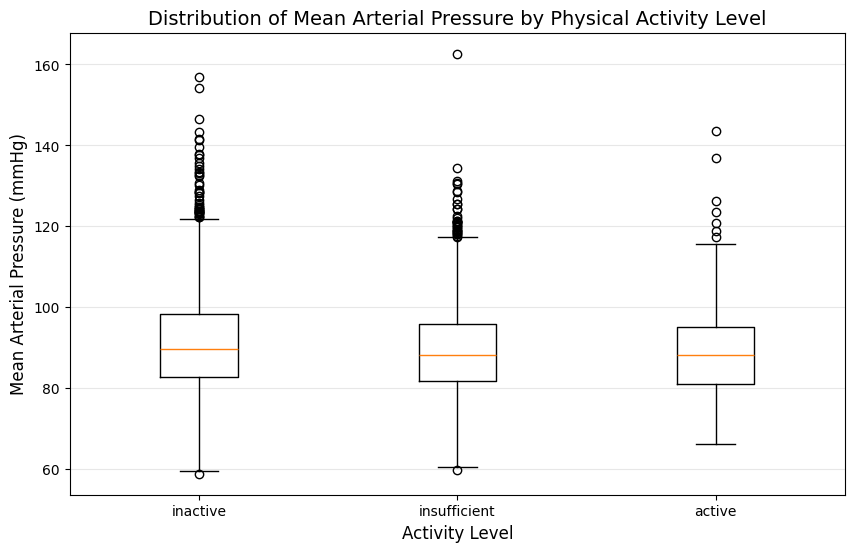

In [657]:
inactive = merged[merged["activity_level"] == "inactive"]["map"]
insufficient = merged[merged["activity_level"] == "insufficient"]["map"]
active = merged[merged["activity_level"] == "active"]["map"]

plt.figure(figsize=(10, 6))
plt.boxplot([inactive, insufficient, active], tick_labels=["inactive", "insufficient", "active"])
plt.title("Distribution of Mean Arterial Pressure by Physical Activity Level", fontsize=14)
plt.xlabel("Activity Level", fontsize=12)
plt.ylabel("Mean Arterial Pressure (mmHg)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('figures/map_distribution_by_activity_level.png', dpi=300, bbox_inches='tight')
plt.show()

In [658]:
merged.groupby("activity_level")["map"].mean()

activity_level
active          88.887132
inactive        91.199826
insufficient    89.529541
Name: map, dtype: float64

Figure 1. Boxplot of Mean Arterial Pressure (mmHg) across three physical activity levels. 

The inactive group has the highest average MAP (~ 91.20 mmHg), followed by the insufficient group (~ 89.53 mmHg), while the active participants had the lowest average MAP (~ 88.89 mmHg). The difference is not visually convincing, as all three boxes sit in roughly the same range and overlap, suggesting that activity level alone does not strongly separate MAP distributions in this sample, even though the a trend exists (higher activity associated with lower MAP).

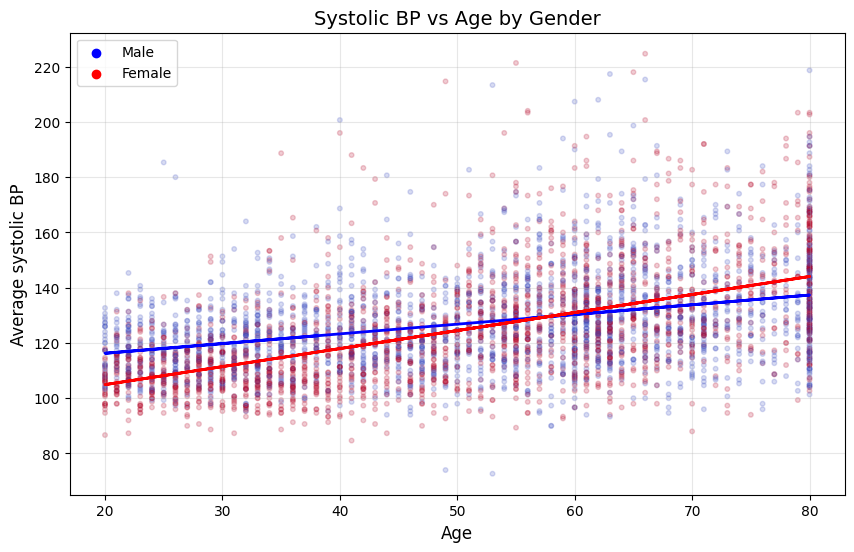

In [659]:
x = merged["RIDAGEYR"]
y = merged["bp_sys_avg"]
colors = merged["RIAGENDR"]

plt.figure(figsize=(10,6))
plt.grid(alpha=0.3)
plt.scatter(x, y, c=colors, cmap="coolwarm", s=11, alpha=0.2)

male = merged[merged["RIAGENDR"] == 1]
female = merged[merged["RIAGENDR"] == 2]

z_male = np.polyfit(male["RIDAGEYR"], male["bp_sys_avg"], 1)
plt.plot(male["RIDAGEYR"], np.poly1d(z_male)(male["RIDAGEYR"]), color="blue", linewidth=2)

z_female = np.polyfit(female["RIDAGEYR"], female["bp_sys_avg"], 1)
plt.plot(female["RIDAGEYR"], np.poly1d(z_female)(female["RIDAGEYR"]), color="red", linewidth=2)

plt.title("Systolic BP vs Age by Gender", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Average systolic BP", fontsize=12)

plt.scatter([], [], color="blue", label="Male")
plt.scatter([], [], color="red", label="Female")
plt.legend()
plt.savefig('figures/systolic_bp_age_by_gender_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 2. Systolic BP increases steadily with age for both males and females. Males start higher (~117 mmHg at age 20) but have a shallower slope, while females start lower (~105 mmHg) but rise more steeply, crossing over and slightly exceeding males by around age 55-60.

In [660]:
percent_data = merged.groupby("income_group")["hypertension"].mean()*100
percent_data

income_group
below poverty    54.662841
high income      56.003937
middle income    59.962929
near poverty     57.851240
Name: hypertension, dtype: float64

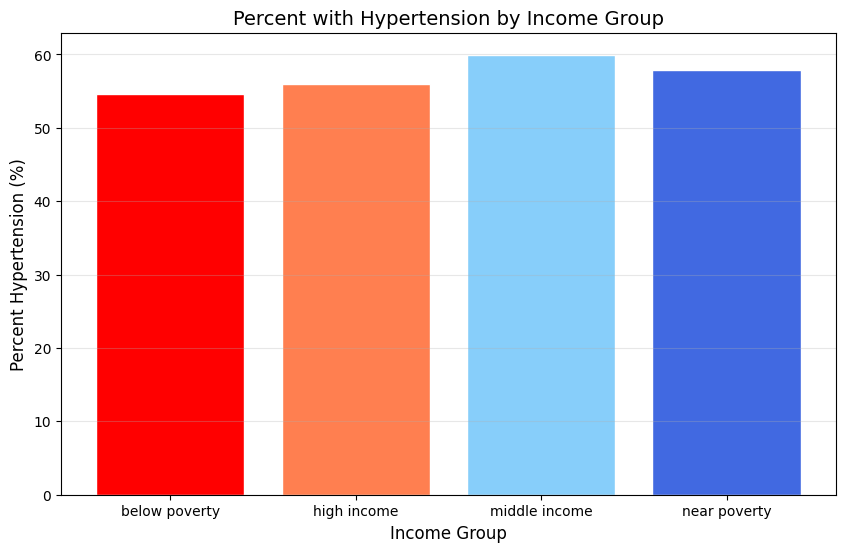

In [661]:
plt.figure(figsize=(10,6))
plt.bar(percent_data.index, percent_data.values, color=['red', 'coral', 'lightskyblue', 'royalblue'], edgecolor='white')
plt.title("Percent with Hypertension by Income Group", fontsize=14)
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Percent Hypertension (%)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('figures/hypertension_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 3. Middle income (~ 59.96%) and near poverty (~ 57.85%) groups have the highest hypertension rates, while below poverty (~ 54.66%) and high income (~ 56.0%) are slightly lower. So hypertension does not consistently increase as income decreases, the pattern is mixed. One real-world reason the below poverty group may appear lower is lack of healthcare access, which means people who cannot afford regular check-ups are less likely to have ever been formally diagnosed, meaning true hypertension in that group is likely undercounted.